In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, r2_score, mean_squared_error)

In [8]:
df = pd.read_csv("Titanic Dataset.csv")

In [9]:
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())

df = df.drop(columns=["body", "cabin", "boat", "home.dest"])

X = df[["pclass", "sex", "age", "sibsp", "parch", "fare"]]
y = df["survived"] 

print(X.dtypes)        # everything should be numeric
print(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.isnull().sum())

pclass      int64
sex         int64
age       float64
sibsp       int64
parch       int64
fare      float64
dtype: object
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64


In [10]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",1,29.00,0,0,24160,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",0,0.92,1,2,113781,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",1,2.00,1,2,113781,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",0,30.00,1,2,113781,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.00,1,2,113781,151.5500,S


In [12]:
# 1. Instantiate the model
model1 = LogisticRegression(solver='liblinear')
model1.fit(X_train, y_train)

# 2. Define the grid
# We want to test L1 vs L2 AND different strengths (C)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0, 1]  # 0=L2, 1=L1 (replaces 'penalty')
}

# 3. Run GridSearch

grid_log = GridSearchCV(model1, param_grid, cv=5, scoring='accuracy')
grid_log.fit(X_train, y_train)

if grid_log.best_params_['l1_ratio']==0:
    print("Best Penalty: L2 (Ridge)")
print(f"Best C: {grid_log.best_params_['C']}")
best_log_model = grid_log.best_estimator_

Best Penalty: L2 (Ridge)
Best C: 0.1


The best penalty was L2, or ridge. This means that the model considers all features. The best C parameter was 0.1. This means that the penalty is balanced.

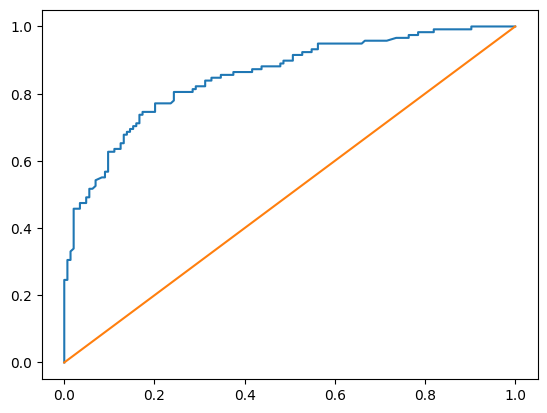

AUC score: 0.85237170433145


In [13]:
y_prob = model1.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.show()

print(f'AUC score: {auc}')

In [14]:
df2 = pd.read_csv("spotifytop2019.csv")

In [15]:
df2 =df2.drop(columns=['id','name','artists'])

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df2[['danceability', 'energy', 'loudness', 'tempo']] = scaler.fit_transform(df2[['danceability', 'energy', 'loudness', 'tempo']])

X = df2[["speechiness", "acousticness", "liveness", "energy", 
        "key", "loudness", "mode", "instrumentalness", 
        "valence", "tempo", "duration_ms"]]
y = df2["danceability"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
df2.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.101911,-0.358068,9.0,-0.105044,0.0,0.0290,0.0392,0.00,0.0828,0.749,0.020952,190800.0,4.0
1,-0.267516,-0.937574,7.0,-1.885719,1.0,0.3750,0.3280,0.13,0.1000,0.562,0.473137,194088.0,4.0
2,0.076433,-0.480565,2.0,0.503849,1.0,0.0575,0.5330,0.00,0.0685,0.925,-0.651487,157560.0,4.0
3,0.222930,-1.446408,1.0,-1.801322,0.0,0.3340,0.5920,0.00,0.0881,0.327,0.595639,178627.0,4.0
4,0.859873,-0.023557,6.0,0.072082,1.0,0.1020,0.0533,0.00,0.1130,0.639,0.495870,157067.0,4.0


In [22]:
model2 = Lasso()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(model2, param_grid, cv=5, 
                          scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

An alpha of 0.0001 was the best value. This means there is a low penalty, and the model is not penalizing complexity. It is probably overfitting.

In [24]:
model3 = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(model3, param_grid, cv=5, 
                          scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

An alpha of 0.01 was the best value. This means there is an about balanced penalty, and the model is probably the best.